C:\Users\user\AppData\Local\Temp\ipykernel_27172\1609230708.py:35: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[ 0.50494151 -0.16282241  0.67188249 ...  0.00411857 -1.66529123
 -0.83058633]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df_selected.loc[:, numeric_cols] = scaler.fit_transform(df_selected[numeric_cols])
C:\Users\user\AppData\Local\Temp\ipykernel_27172\1609230708.py:35: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[ 0.34837541 -1.38373605  1.56085343 ...  0.86800885  0.52158655
 -1.12391933]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df_selected.loc[:, numeric_cols] = scaler.fit_transform(df_selected[numeric_cols])
C:\Users\user\AppData\Local\Temp\ipykernel_27172\1609230708.py:35: FutureWarning: Setting an item of incompatible dtype is dep

      Motivation_Level_High  Motivation_Level_Low  Motivation_Level_Medium  \
0                       0.0                   1.0                      0.0   
1                       0.0                   1.0                      0.0   
2                       0.0                   0.0                      1.0   
3                       0.0                   0.0                      1.0   
4                       0.0                   0.0                      1.0   
...                     ...                   ...                      ...   
6602                    0.0                   0.0                      1.0   
6603                    0.0                   0.0                      1.0   
6604                    0.0                   1.0                      0.0   
6605                    1.0                   0.0                      0.0   
6606                    0.0                   0.0                      1.0   

      Parental_Involvement_High  Parental_Involvement_Low  \
0 

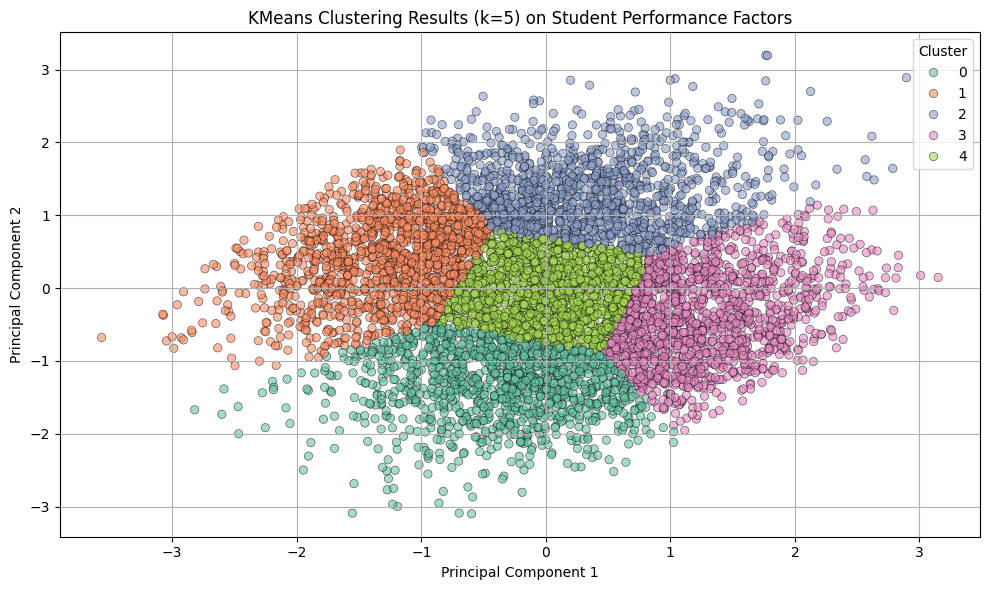

Cluster attribute breakdown:

         Hours_Studied  Attendance  Previous_Scores Motivation_Level  \
Cluster                                                                
0            14.032636   69.594142        69.133891           Medium   
1            17.032751   91.633188        63.701601           Medium   
2            25.595711   90.403495        81.487689           Medium   
3            22.959273   68.645818        86.417455           Medium   
4            19.950855   79.156695        74.382479           Medium   

        Parental_Involvement  
Cluster                       
0                     Medium  
1                     Medium  
2                     Medium  
3                     Medium  
4                     Medium  


In [1]:
import pandas as pd
import numpy as np
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
df = pd.read_csv("Student Performance.csv")

# Select the 5 most relevant features
selected_features = [
    "Hours_Studied",
    "Attendance",
    "Previous_Scores",
    "Motivation_Level",
    "Parental_Involvement"
]

df_selected = df[selected_features]

# Separate numeric and categorical
numeric_cols = ["Hours_Studied", "Attendance", "Previous_Scores"]
categorical_cols = ["Motivation_Level", "Parental_Involvement"]

# Handle missing values - numeric
num_imputer = SimpleImputer(strategy="mean")
df_selected.loc[:, numeric_cols] = num_imputer.fit_transform(df_selected[numeric_cols])

# Normalize numeric features
scaler = StandardScaler()
df_selected.loc[:, numeric_cols] = scaler.fit_transform(df_selected[numeric_cols])

# Handle missing values - categorical
cat_imputer = SimpleImputer(strategy="most_frequent")
df_selected.loc[:, categorical_cols] = cat_imputer.fit_transform(df_selected[categorical_cols])

# One-hot encode categorical columns
encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
encoded_cats = encoder.fit_transform(df_selected[categorical_cols])
encoded_cat_df = pd.DataFrame(encoded_cats, columns=encoder.get_feature_names_out(categorical_cols))
print(encoded_cat_df)

# Combine numeric and encoded categorical
final_df = pd.concat([df_selected[numeric_cols], encoded_cat_df], axis=1)

# Apply PCA for dimensionality reduction (2D)
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(final_df)

# KMeans clustering with k=5
kmeans = KMeans(n_clusters=5, random_state=42)
labels = kmeans.fit_predict(X_pca)

# Evaluation using a 1000-sample subset
sample_indices = np.random.choice(X_pca.shape[0], size=1000, replace=False)
X_sample = X_pca[sample_indices]
labels_sample = labels[sample_indices]

sil_score = silhouette_score(X_sample, labels_sample)
db_score = davies_bouldin_score(X_sample, labels_sample)

# Print scores
print("Silhouette Score:", sil_score)
print("Davies-Bouldin Score:", db_score)

# Visualize clustering result
plot_df = pd.DataFrame(X_pca, columns=["pc_1", "pc_2"])
plot_df["cluster"] = labels

plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=plot_df,
    x="pc_1", y="pc_2",
    hue="cluster",
    palette="Set2",
    alpha=0.6,
    edgecolor='k'
)

plt.title("KMeans Clustering Results (k=5) on Student Performance Factors")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend(title="Cluster")
plt.grid(True)
plt.tight_layout()
plt.show()

# Append the cluster labels back to the original data
original_data_with_labels = df[selected_features].copy()
original_data_with_labels["Cluster"] = labels

# Group by cluster and show average (or mode for categorical)
summary = original_data_with_labels.groupby("Cluster").agg({
    "Hours_Studied": "mean",
    "Attendance": "mean",
    "Previous_Scores": "mean",
    "Motivation_Level": lambda x: x.mode()[0],
    "Parental_Involvement": lambda x: x.mode()[0]
})

print("Cluster attribute breakdown:\n")
print(summary)